# Data Preprocessing - Clinical Trial Failure Prediction

---

## Mục tiêu

**Dự đoán Success vs Fail của thử nghiệm lâm sàng ung thư trên dữ liệu ClinicalTrials.gov.**

| Item | Description |
|------|-------------|
| **Task** | Binary Classification |
| **Scope** | `INTERVENTIONAL` + `Phase 2-3` + keyword `"cancer"` |
| **Label** | `label_binary`: **1** = Success (Completed), **0** = Fail (Withdrawn, Terminated) |
| **Columns** | **23 cột cố định** (không thêm/bớt) |

---

## 23 Cột Dữ liệu

| # | Column | Type | Description |
|---|--------|------|-------------|
| 1 | `nct_id` | ID | Trial identifier |
| 2 | `brief_title` | Text | Short title |
| 3 | `overall_status` | Category | Trial status (source of label) |
| 4 | `start_date` | Date | Trial start date |
| 5 | `completion_date` | Date | Trial completion date |
| 6 | `study_type` | Category | INTERVENTIONAL |
| 7 | `phases` | Category | PHASE2, PHASE3, PHASE2\|PHASE3 |
| 8 | `allocation` | Category | RANDOMIZED, etc. |
| 9 | `intervention_model` | Category | PARALLEL, SINGLE_GROUP, etc. |
| 10 | `primary_purpose` | Category | TREATMENT, etc. |
| 11 | `masking` | Category | DOUBLE, SINGLE, NONE, etc. |
| 12 | `enrollment_count` | Numeric | Number of participants |
| 13 | `enrollment_type` | Category | ACTUAL, ESTIMATED |
| 14 | `lead_sponsor_name` | Text | Sponsor name |
| 15 | `lead_sponsor_class` | Category | INDUSTRY, NIH, etc. |
| 16 | `has_dmc` | Boolean | Has Data Monitoring Committee |
| 17 | `conditions` | Text | Disease conditions |
| 18 | `num_conditions` | Numeric | Count of conditions |
| 19 | `intervention_types` | Text | Types of interventions |
| 20 | `intervention_names` | Text | Intervention names |
| 21 | `num_interventions` | Numeric | Count of interventions |
| 22 | `num_arms` | Numeric | Number of arms |
| 23 | `has_results` | Boolean | Has posted results |

---

## Notebook Structure

| # | Section | Content |
|---|---------|---------|
| 1 | Setup | Imports, paths, config |
| 2 | Load & Validate | Load CSV, select 23 columns, validate dtypes |
| 3 | Missing Analysis | Missingness table, visualization |
| 4 | Missing Handling | Impute/fill strategies |
| 5 | EDA & Visualization | Class balance, feature distributions |
| 6 | Create df_clean | Final dataset for feature engineering |
| 7 | Save Output | Export `ctgov_cancer_phase23_clean.csv` |

---

---

## 1️⃣ Setup & Configuration

### 1.1 Import library: 

In [1]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Project paths
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

### 1.2. Import for project: 

In [2]:
from src.data.data_cleaner import (
    PreprocessConfig,
    load_raw_data,
    standardize_dtypes,
    analyze_missing,
    split_data,
    sanity_checks,
    create_data_dictionary,
    compute_checksum
)

# Import visualization modules (new API)
from src.visualization import plot_utils as pu
from src.visualization.dashboard import InteractiveDashboard

# For stratified k-fold cross-validation
from sklearn.model_selection import StratifiedKFold

### 1.3. Configuation: 

In [3]:
# ============================================================================
# CONFIGURATION
# ============================================================================
SEED = 42
np.random.seed(SEED)

# Input/Output paths
INPUT_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "eda_plots"

# Create output directories
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Find input file
csv_files = sorted(INPUT_DIR.glob("ctgov_flat*.csv"))
INPUT_FILE = csv_files[-1] if csv_files else None

if INPUT_FILE is None:
    raise FileNotFoundError("No ctgov_flat*.csv found!")

# 23 columns to keep (as specified in project requirements)
COLUMNS_23 = [
    'nct_id', 'brief_title', 'overall_status', 'start_date', 'completion_date',
    'study_type', 'phases', 'allocation', 'intervention_model', 'primary_purpose',
    'masking', 'enrollment_count', 'enrollment_type', 'lead_sponsor_name',
    'lead_sponsor_class', 'has_dmc', 'conditions', 'num_conditions',
    'intervention_types', 'intervention_names', 'num_interventions',
    'num_arms', 'has_results'
]

# Label definition
SUCCESS_STATUSES = ['COMPLETED']
FAIL_STATUSES = ['WITHDRAWN', 'TERMINATED']

# Initialize interactive dashboard
dashboard = InteractiveDashboard(theme='plotly_white')


### 1.4. Status: 

In [ ]:
print("=" * 80)
print("SETUP COMPLETE - Data Preprocessing Pipeline")
print("=" * 80)
print(f"Modules loaded:")
print(f"   • data_cleaner: 8 core functions")
print(f"   • plot_utils: Academic-grade visualization functions")
print(f"   • dashboard: Interactive Plotly visualizations")
print(f"   • sklearn: StratifiedKFold for cross-validation")
print(f"\nConfiguration:")
print(f"   • Random seed: {SEED}")
print(f"   • Input file: {INPUT_FILE.name}")
print(f"   • Output directory: {OUTPUT_DIR}")
print(f"   • Figures directory: {FIGURES_DIR}")
print(f"   • Columns to analyze: {len(COLUMNS_23)}")
print(f"   • Success statuses: {SUCCESS_STATUSES}")
print(f"   • Fail statuses: {FAIL_STATUSES}")
print("=" * 80)

SETUP COMPLETE - Data Preprocessing Pipeline
Modules loaded:
   • data_cleaner: 8 core functions
   • plot_utils: Academic-grade visualization functions
   • dashboard: Interactive Plotly visualizations
   • sklearn: StratifiedKFold for cross-validation

🔧 Configuration:
   • Random seed: 42
   • Input file: ctgov_flat.csv
   • Output directory: /home/lang-phu-quy/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction/data/processed
   • Figures directory: /home/lang-phu-quy/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction/reports/figures/eda_plots
   • Columns to analyze: 23
   • Success statuses: ['COMPLETED']
   • Fail statuses: ['WITHDRAWN', 'TERMINATED']


---

## 2️⃣ Load Data & Chuẩn hóa Kiểu Dữ liệu

> **Mục tiêu**: Load CSV, chọn 23 cột, ép kiểu rõ ràng theo spec.

In [ ]:
# ============================================================================
# 2.1 LOAD RAW DATA (using load_raw_data from data_cleaner.py)
# ============================================================================

# Load raw data using module function
df_raw = load_raw_data(INPUT_FILE)

print("=" * 60)
print("LOAD DATA & SELECT 23 COLUMNS")
print("=" * 60)
print(f"Raw shape: {df_raw.shape}")

# Check which columns are available
available_cols = [c for c in COLUMNS_23 if c in df_raw.columns]
missing_cols = [c for c in COLUMNS_23 if c not in df_raw.columns]

print(f"\nAvailable columns: {len(available_cols)}/{len(COLUMNS_23)}")
if missing_cols:
    print(f"Missing columns: {missing_cols}")

# Select 23 columns only
df = df_raw[available_cols].copy()
print(f"\nSelected shape: {df.shape}")

# Quick sanity check
print(f"\nSanity Check:")
print(f"   • Total rows: {len(df):,}")
print(f"   • Unique nct_id: {df['nct_id'].nunique():,}")
print(f"   • Null nct_id: {df['nct_id'].isna().sum()}")

[2025-12-11 22:55:49,149] INFO - Loading data from /home/lang-phu-quy/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction/data/processed/ctgov_flat.csv
[2025-12-11 22:55:49,182] INFO - Loaded 200 rows, 23 columns


LOAD DATA & SELECT 23 COLUMNS
Raw shape: (200, 23)

✅ Available columns: 23/23

📊 Selected shape: (200, 23)

Sanity Check:
   • Total rows: 200
   • Unique nct_id: 200
   • Null nct_id: 0


In [ ]:
# ============================================================================
# 2.1b DATA QUALITY CHECKS (using sanity_checks from data_cleaner)
# ============================================================================

# Run sanity checks using module function
sanity_results = sanity_checks(df)

print("\nData Quality Checks:")
print("=" * 60)
for check, result in sanity_results.items():
    status = "PASS" if result != "FAIL" else "FAIL"
    print(f"{status} {check}: {result}")

# Compute data checksum for reproducibility
data_checksum = compute_checksum(df)
print(f"\nData Checksum (SHA-256): {data_checksum[:16]}...")
print("   → Use this to verify data integrity")


Data Quality Checks:
✅ date_anomalies_count: 0
✅ enrollment_outliers_count: 19
✅ duplicate_nct_ids: 0

Data Checksum (SHA-256): b03ee31616798bdf...
   → Use this to verify data integrity


In [ ]:
# ============================================================================
# 2.2 STANDARDIZE DATA TYPES (using standardize_dtypes from data_cleaner.py)
# ============================================================================

print("=" * 60)
print("STANDARDIZE DATA TYPES")
print("=" * 60)

# Define custom schema for our 23 columns
custom_schema = {
    "date_columns": ["start_date", "completion_date"],
    "numeric_columns": ["enrollment_count", "num_conditions", "num_interventions", "num_arms"],
    "boolean_columns": ["has_dmc", "has_results"],
    "categorical_columns": [
        "overall_status", "study_type", "phases", "allocation",
        "intervention_model", "primary_purpose", "masking", 
        "enrollment_type", "lead_sponsor_class"
    ],
    "text_columns": [
        "brief_title", "lead_sponsor_name", "conditions",
        "intervention_types", "intervention_names"
    ]
}

# Use module function to standardize dtypes
df, dtype_report = standardize_dtypes(df, schema=custom_schema)

print("\nDtype Conversion Report:")
print(dtype_report.to_string(index=False))

# Summary
print("\n" + "-" * 40)
print("Final Dtypes Summary:")
print(df.dtypes.value_counts().to_string())

[2025-12-11 22:55:49,279] INFO - Dtype standardization complete: 22 columns processed


🔄 STANDARDIZE DATA TYPES

Dtype Conversion Report:
            column    category dtype_before    dtype_after  coerced_to_null
        start_date        date       object datetime64[ns]                0
   completion_date        date       object datetime64[ns]                0
  enrollment_count     numeric      float64        float64                0
    num_conditions     numeric        int64          int64                0
 num_interventions     numeric        int64          int64                0
          num_arms     numeric        int64          int64                0
           has_dmc     boolean       object         object                0
       has_results     boolean         bool           bool                0
    overall_status categorical       object         object                0
        study_type categorical       object         object                0
            phases categorical       object         object                0
        allocation categorical       

---

## 3️⃣ Phân tích & Xử lý Missing

### Chiến lược xử lý Missing

| Type | Columns | Strategy |
|------|---------|----------|
| **Numeric** | `enrollment_count` | Median theo `phases` → global median, tạo `enrollment_count_was_missing` |
| **Datetime** | `start_date`, `completion_date` | Giữ NaT, KHÔNG impute |
| **Categorical** | `allocation`, `intervention_model`, `masking`, `enrollment_type`, `lead_sponsor_class`, `lead_sponsor_name` | Fill `'UNKNOWN'` |
| **Boolean** | `has_dmc` | Fill `'UNKNOWN'` (không phải False) |

In [8]:
# ============================================================================
# 3.1 MISSING ANALYSIS (using analyze_missing from data_cleaner.py)
# ============================================================================

print("=" * 60)
print("MISSINGNESS ANALYSIS - 23 COLUMNS")
print("=" * 60)

# Use module function to analyze missing values
missing_analysis = analyze_missing(df, threshold_drop=0.7)

# Extract results
missing_df = missing_analysis["missing_df"]

print("\nMissing Summary Table:")
print("-" * 70)
print(f"{'Column':<25} {'Missing':>10} {'Rate':>12} {'Category':<15}")
print("-" * 70)
for _, row in missing_df.iterrows():
    rate_pct = row['missing_rate'] * 100
    category = "HIGH" if rate_pct > 50 else "MODERATE" if rate_pct > 20 else "LOW"
    print(f"{row['column']:<25} {row['missing_count']:>10,} {rate_pct:>10.1f}% {category:<15}")
print("-" * 70)

# Summary by category
print(f"\nColumn Categories:")
print(f"   • Core (< 30% missing): {len(missing_analysis['core_columns'])} columns")
print(f"   • Optional (30-70% missing): {len(missing_analysis['optional_columns'])} columns")
print(f"   • Drop (> 70% missing): {len(missing_analysis['drop_columns'])} columns")

if missing_analysis['drop_columns']:
    print(f"\nColumns to drop: {missing_analysis['drop_columns']}")

MISSINGNESS ANALYSIS - 23 COLUMNS

Missing Summary Table:
----------------------------------------------------------------------
Column                       Missing         Rate Category       
----------------------------------------------------------------------
masking                          152       76.0% HIGH           
allocation                        86       43.0% MODERATE       
has_dmc                           46       23.0% MODERATE       
intervention_model                16        8.0% LOW            
enrollment_type                   15        7.5% LOW            
enrollment_count                  10        5.0% LOW            
completion_date                   10        5.0% LOW            
start_date                         1        0.5% LOW            
primary_purpose                    1        0.5% LOW            
num_arms                           0        0.0% LOW            
num_interventions                  0        0.0% LOW            
intervention_names 

In [9]:
# ============================================================================
# 3.2 VISUALIZATION: Missing Rate (using plot_utils)
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 8))
pu.plot_missing_rates(df, top_n=25, ax=ax)
pu.save_fig(fig, FIGURES_DIR / 'missing_values_overview.png')
plt.show()

print("\nMissing values visualization saved to figures directory")



Missing values visualization saved to figures directory


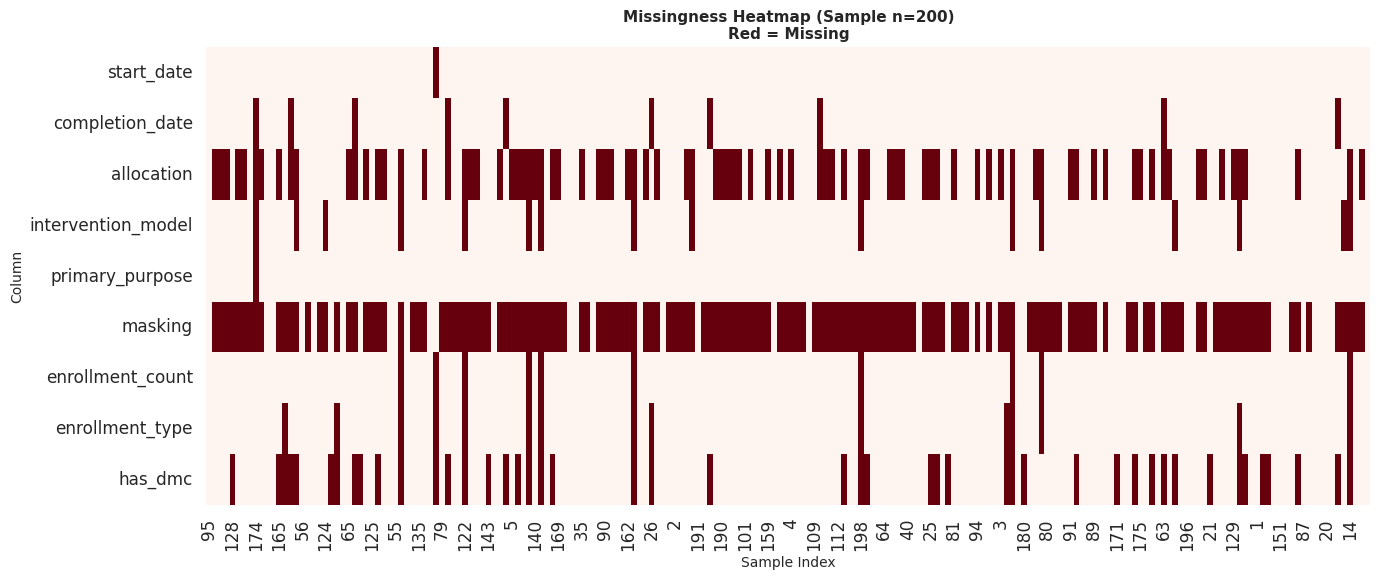

In [10]:
# ============================================================================
# 3.3 MISSINGNESS HEATMAP (sample visualization)
# ============================================================================

# Sample for visualization
sample_size = min(500, len(df))
df_sample = df.sample(n=sample_size, random_state=SEED)

fig, ax = plt.subplots(figsize=(14, 6))
missing_matrix = df_sample.isnull().astype(int)

# Only show columns with some missing
cols_with_missing = [c for c in missing_matrix.columns if missing_matrix[c].sum() > 0]
if cols_with_missing:
    sns.heatmap(missing_matrix[cols_with_missing].T, cmap='Reds', cbar=False, ax=ax)
    ax.set_xlabel('Sample Index', fontsize=10)
    ax.set_ylabel('Column', fontsize=10)
    ax.set_title(f'Missingness Heatmap (Sample n={sample_size})\nRed = Missing', fontsize=11, fontweight='bold')
else:
    ax.text(0.5, 0.5, 'No missing values in sample', ha='center', va='center', fontsize=14)
    ax.set_title('Missingness Heatmap', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### 3.4 Xử lý Missing Values

In [11]:
# ============================================================================
# 3.4a NUMERIC: enrollment_count - Median imputation by phase
# ============================================================================

print("=" * 60)
print("MISSING HANDLING: ENROLLMENT_COUNT")
print("=" * 60)

df_clean = df.copy()

# Create indicator BEFORE imputation
df_clean['enrollment_count_was_missing'] = df_clean['enrollment_count'].isna().astype(int)
missing_before = df_clean['enrollment_count'].isna().sum()
print(f"\nenrollment_count missing: {missing_before:,} ({missing_before/len(df_clean)*100:.1f}%)")
print(f"Created 'enrollment_count_was_missing' indicator")

# Impute with median by phases, fallback to global median
if 'phases' in df_clean.columns:
    # Group median
    group_median = df_clean.groupby('phases')['enrollment_count'].transform('median')
    n_group_fill = (df_clean['enrollment_count'].isna() & group_median.notna()).sum()
    df_clean['enrollment_count'] = df_clean['enrollment_count'].fillna(group_median)
    print(f"Imputed by phase median: {n_group_fill:,}")

# Global median fallback
global_median = df_clean['enrollment_count'].median()
n_fallback = df_clean['enrollment_count'].isna().sum()
df_clean['enrollment_count'] = df_clean['enrollment_count'].fillna(global_median)
print(f"Imputed by global median ({global_median:.0f}): {n_fallback:,}")

missing_after = df_clean['enrollment_count'].isna().sum()
print(f"\nenrollment_count after: {missing_after} missing")

MISSING HANDLING: ENROLLMENT_COUNT

enrollment_count missing: 10 (5.0%)
Created 'enrollment_count_was_missing' indicator
Imputed by phase median: 10
Imputed by global median (42): 0

enrollment_count after: 0 missing


In [12]:
# ============================================================================
# 3.4b CATEGORICAL: Fill with 'UNKNOWN'
# ============================================================================

print("=" * 60)
print("MISSING HANDLING: CATEGORICAL COLUMNS")
print("=" * 60)

cat_fill_cols = ['allocation', 'intervention_model', 'masking', 
                 'enrollment_type', 'lead_sponsor_class', 'primary_purpose']

cat_fill_log = []
for col in cat_fill_cols:
    if col in df_clean.columns:
        missing_count = df_clean[col].isna().sum()
        if missing_count > 0:
            df_clean[col] = df_clean[col].fillna('UNKNOWN')
            cat_fill_log.append({'column': col, 'filled': missing_count, 'fill_value': 'UNKNOWN'})
            print(f"{col}: {missing_count:,} → filled with 'UNKNOWN'")

# lead_sponsor_name (text column) - fill empty with 'UNKNOWN'
if 'lead_sponsor_name' in df_clean.columns:
    empty_mask = df_clean['lead_sponsor_name'].isna() | (df_clean['lead_sponsor_name'].astype(str).str.strip() == '')
    n_empty = empty_mask.sum()
    if n_empty > 0:
        df_clean.loc[empty_mask, 'lead_sponsor_name'] = 'UNKNOWN'
        print(f"lead_sponsor_name: {n_empty:,} → filled with 'UNKNOWN'")

MISSING HANDLING: CATEGORICAL COLUMNS
allocation: 86 → filled with 'UNKNOWN'
intervention_model: 16 → filled with 'UNKNOWN'
masking: 152 → filled with 'UNKNOWN'
enrollment_type: 15 → filled with 'UNKNOWN'
primary_purpose: 1 → filled with 'UNKNOWN'


In [13]:
# ============================================================================
# 3.4c BOOLEAN: has_dmc → Fill with 'UNKNOWN' (not False)
# ============================================================================

print("=" * 60)
print("MISSING HANDLING: has_dmc")
print("=" * 60)

if 'has_dmc' in df_clean.columns:
    # Convert to string for proper handling
    df_clean['has_dmc'] = df_clean['has_dmc'].astype(str)
    
    # Count and fill missing
    missing_mask = df_clean['has_dmc'].isin(['nan', 'None', '<NA>', '', 'NaN'])
    missing_count = missing_mask.sum()
    
    if missing_count > 0:
        df_clean.loc[missing_mask, 'has_dmc'] = 'UNKNOWN'
        print(f"has_dmc: {missing_count:,} → filled with 'UNKNOWN' (not False)")
        print("   Rationale: Missing DMC info ≠ No DMC, it means UNKNOWN")
    else:
        print("has_dmc: No missing values")

MISSING HANDLING: has_dmc
has_dmc: 46 → filled with 'UNKNOWN' (not False)
   Rationale: Missing DMC info ≠ No DMC, it means UNKNOWN


In [14]:
# ============================================================================
# 3.4d DATETIME: Giữ NaT - KHÔNG impute
# ============================================================================

print("=" * 60)
print("DATETIME COLUMNS: NO IMPUTATION")
print("=" * 60)

print("Policy:")
print("   • start_date: Giữ NaT, dùng cho split/anti-leakage")
print("   • completion_date: Giữ NaT, chỉ dùng cho EDA")
print()

for col in ['start_date', 'completion_date']:
    if col in df_clean.columns:
        missing = df_clean[col].isna().sum()
        print(f"   {col}: {missing:,} NaT ({missing/len(df_clean)*100:.1f}%)")

DATETIME COLUMNS: NO IMPUTATION
Policy:
   • start_date: Giữ NaT, dùng cho split/anti-leakage
   • completion_date: Giữ NaT, chỉ dùng cho EDA

   start_date: 1 NaT (0.5%)
   completion_date: 10 NaT (5.0%)


In [15]:
# ============================================================================
# 3.5 MISSING SUMMARY AFTER HANDLING (Verification)
# ============================================================================

print("=" * 60)
print("MISSING SUMMARY AFTER HANDLING")
print("=" * 60)

# Use analyze_missing again to verify
missing_after_analysis = analyze_missing(df_clean, threshold_drop=0.7)
missing_after_df = missing_after_analysis["missing_df"]

print("\nMissing After Processing (non-zero only):")
print("-" * 50)
non_zero = missing_after_df[missing_after_df['missing_rate'] > 0]
if len(non_zero) > 0:
    for _, row in non_zero.iterrows():
        if row['column'] != 'enrollment_count_was_missing':  # Skip indicator
            print(f"   {row['column']:<25}: {row['missing_rate']*100:.1f}%")
else:
    print("   All columns have 0% missing (except datetime NaT allowed)")

# Date columns allowed to have NaT
print("\nDatetime columns (NaT allowed):")
for col in ['start_date', 'completion_date']:
    if col in df_clean.columns:
        missing = df_clean[col].isna().sum()
        print(f"   {col}: {missing:,} NaT ({missing/len(df_clean)*100:.1f}%)")

MISSING SUMMARY AFTER HANDLING

Missing After Processing (non-zero only):
--------------------------------------------------
   completion_date          : 5.0%
   start_date               : 0.5%

Datetime columns (NaT allowed):
   start_date: 1 NaT (0.5%)
   completion_date: 10 NaT (5.0%)


---

## 4️⃣ EDA & Visualization

### 4.1 Tạo Label Binary

In [16]:
# ============================================================================
# 4.1 CREATE LABEL_BINARY
# ============================================================================

print("=" * 60)
print("CREATE LABEL_BINARY")
print("=" * 60)

print("\nLabel Definition:")
print(f"   • label_binary = 1 (Success): {SUCCESS_STATUSES}")
print(f"   • label_binary = 0 (Fail): {FAIL_STATUSES}")

# Check current overall_status distribution
print("\noverall_status distribution BEFORE label:")
status_counts = df_clean['overall_status'].value_counts()
print(status_counts.head(10).to_string())

# Create label
df_clean['label_binary'] = np.nan

# Success = 1
success_mask = df_clean['overall_status'].str.upper().isin([s.upper() for s in SUCCESS_STATUSES])
df_clean.loc[success_mask, 'label_binary'] = 1

# Fail = 0
fail_mask = df_clean['overall_status'].str.upper().isin([s.upper() for s in FAIL_STATUSES])
df_clean.loc[fail_mask, 'label_binary'] = 0

# Count
n_success = (df_clean['label_binary'] == 1).sum()
n_fail = (df_clean['label_binary'] == 0).sum()
n_other = df_clean['label_binary'].isna().sum()

print(f"\nLabel Distribution:")
print(f"   • Success (1): {n_success:,} ({n_success/len(df_clean)*100:.1f}%)")
print(f"   • Fail (0):    {n_fail:,} ({n_fail/len(df_clean)*100:.1f}%)")
print(f"   • Other/Drop:  {n_other:,} ({n_other/len(df_clean)*100:.1f}%)")

# Drop rows without valid label
print(f"\nDropping {n_other:,} rows with invalid status (Active, Recruiting, Unknown, etc.)")
df_clean = df_clean.dropna(subset=['label_binary'])
df_clean['label_binary'] = df_clean['label_binary'].astype(int)

print(f"\nFinal shape after label filter: {df_clean.shape}")

CREATE LABEL_BINARY

Label Definition:
   • label_binary = 1 (Success): ['COMPLETED']
   • label_binary = 0 (Fail): ['WITHDRAWN', 'TERMINATED']

overall_status distribution BEFORE label:
overall_status
COMPLETED     148
TERMINATED     41
WITHDRAWN      11

Label Distribution:
   • Success (1): 148 (74.0%)
   • Fail (0):    52 (26.0%)
   • Other/Drop:  0 (0.0%)

Dropping 0 rows with invalid status (Active, Recruiting, Unknown, etc.)

Final shape after label filter: (200, 25)


### 4.2 Visualization: Class Balance

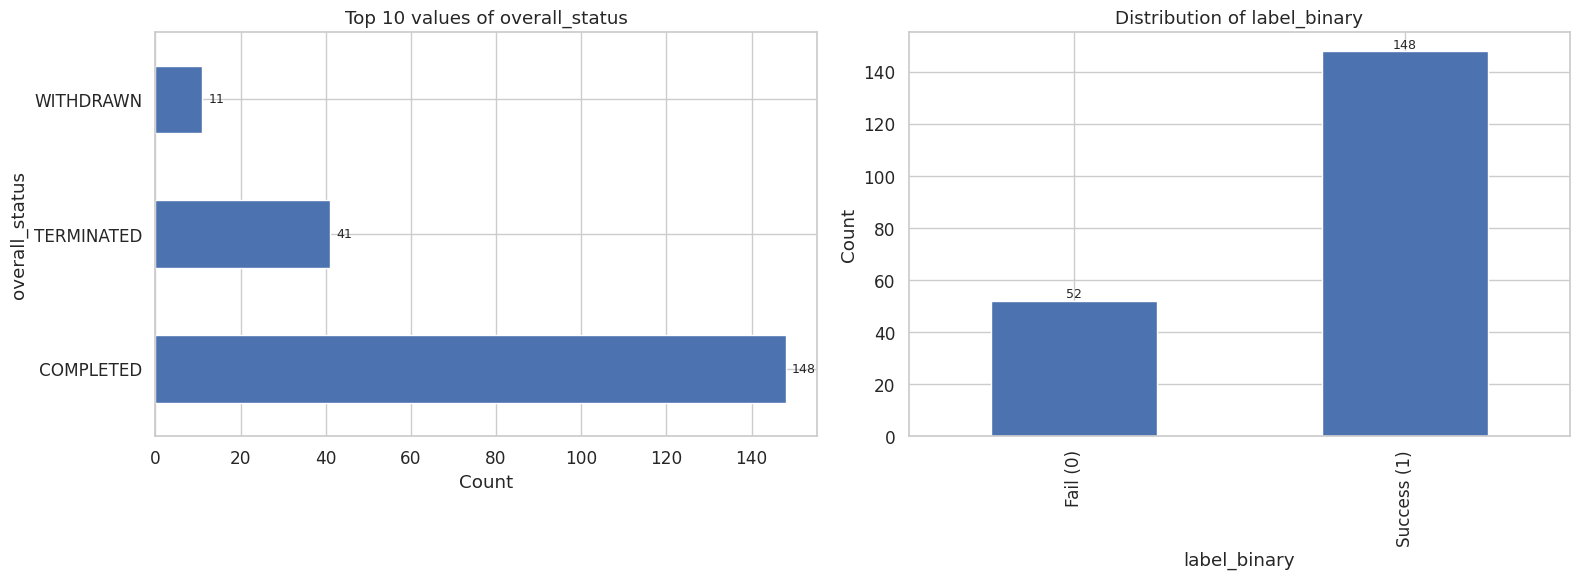


CLASS BALANCE ANALYSIS
Total samples: 200
Success (1):   148 (74.00%)
Fail (0):      52 (26.00%)
Imbalance ratio: 2.85:1
Figure saved to /home/lang-phu-quy/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction/reports/figures/eda_plots/label_distribution.png


In [17]:
# ============================================================================
# 4.2a VISUALIZATION: Label Distribution (using plot_utils)
# ============================================================================

# Overall Status Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Overall Status (top categories using plot_utils)
pu.plot_top_categories(
    df_clean, 
    col='overall_status', 
    top_n=10, 
    horizontal=True, 
    ax=axes[0]
)

# Plot 2: Label Binary Distribution (using plot_utils)
pu.plot_target_distribution(
    df_clean,
    target_col='label_binary',
    ax=axes[1],
    normalize=False
)
axes[1].set_xticklabels(['Fail (0)', 'Success (1)'])

plt.tight_layout()

# Show first
plt.show()

# Then save
pu.save_fig(fig, FIGURES_DIR / 'label_distribution.png')

# Calculate and display class imbalance metrics
n_success = (df_clean['label_binary'] == 1).sum()
n_fail = (df_clean['label_binary'] == 0).sum()
total = len(df_clean)
imbalance_ratio = max(n_success, n_fail) / min(n_success, n_fail)

print(f"\n" + "="*80)
print("CLASS BALANCE ANALYSIS")
print("="*80)
print(f"Total samples: {total:,}")
print(f"Success (1):   {n_success:,} ({n_success/total*100:.2f}%)")
print(f"Fail (0):      {n_fail:,} ({n_fail/total*100:.2f}%)")
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")
print(f"Figure saved to {FIGURES_DIR / 'label_distribution.png'}")
print("="*80)

Recommendation: Use stratified sampling and consider class weights for model training to handle class imbalance.

LABEL DISTRIBUTION BY PHASE
               Fail (0)  Success (1)  Total
phases                                     
PHASE1|PHASE2         8           23     31
PHASE2               35           89    124
PHASE2|PHASE3         1            4      5
PHASE3                8           32     40
All                  52          148    200


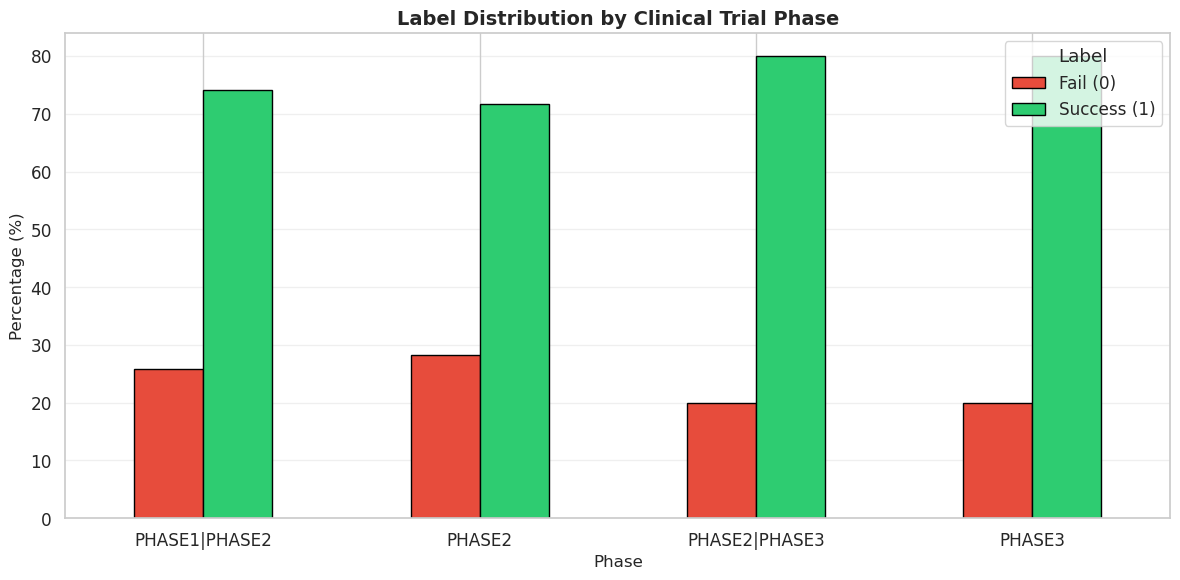


Visualization saved to figures directory


In [18]:
# ============================================================================
# 4.2b VISUALIZATION: Label Distribution by Phase
# ============================================================================

# Create crosstab for phases vs label
phase_label_ct = pd.crosstab(
    df_clean['phases'], 
    df_clean['label_binary'],
    margins=True
)
phase_label_ct.columns = ['Fail (0)', 'Success (1)', 'Total']

print("LABEL DISTRIBUTION BY PHASE")
print("="*80)
print(phase_label_ct)
print("="*80)

# Visualize with grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))
phase_label_pct = pd.crosstab(
    df_clean['phases'], 
    df_clean['label_binary'],
    normalize='index'
) * 100

phase_label_pct.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='black')
ax.set_title('Label Distribution by Clinical Trial Phase', fontsize=14, fontweight='bold')
ax.set_xlabel('Phase', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(['Fail (0)', 'Success (1)'], title='Label')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()

# Show first
plt.show()

# Then save
pu.save_fig(fig, FIGURES_DIR / 'label_by_phase.png')

print("\nVisualization saved to figures directory")


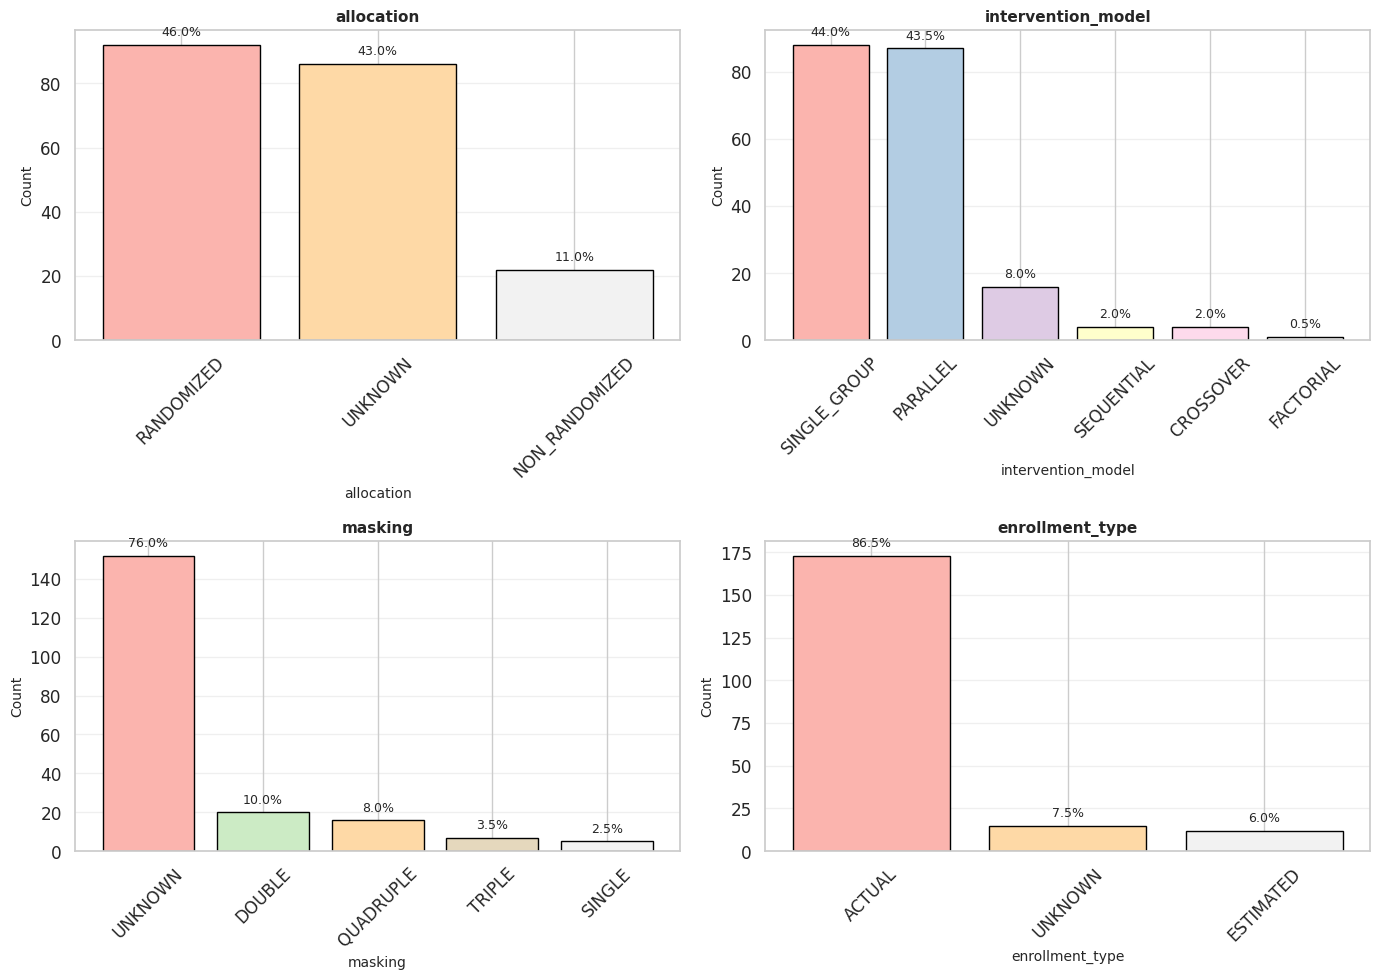

In [19]:
# ============================================================================
# 4.2c BARPLOT: categorical features distribution
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cat_cols = ['allocation', 'intervention_model', 'masking', 'enrollment_type']

for ax, col in zip(axes.flatten(), cat_cols):
    if col in df_clean.columns:
        counts = df_clean[col].astype(str).value_counts().head(6)
        colors = plt.cm.Pastel1(np.linspace(0, 1, len(counts)))
        
        bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='black')
        
        for bar, val in zip(bars, counts.values):
            pct = val / len(df_clean) * 100
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + counts.max()*0.02,
                    f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
        
        ax.set_xlabel(col, fontsize=10)
        ax.set_ylabel('Count', fontsize=10)
        ax.set_title(f'{col}', fontsize=11, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# ============================================================================
# 4.3 ENROLLMENT ANALYSIS (Academic Standard)
# ============================================================================

# Create comprehensive enrollment analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Histogram with KDE
pu.plot_numeric_hist(
    df_clean, 
    col='enrollment_count', 
    bins=50, 
    kde=True, 
    ax=axes[0, 0]
)

# Plot 2: Boxplot by label
df_clean.boxplot(
    column='enrollment_count',
    by='label_binary',
    ax=axes[0, 1],
    showfliers=False
)
axes[0, 1].set_title('Enrollment Count by Label (Outliers Hidden)')
axes[0, 1].set_xlabel('Label (0=Fail, 1=Success)')
axes[0, 1].set_ylabel('Enrollment Count')
plt.suptitle('')

# Plot 3: Log-scale histogram
axes[1, 0].hist(np.log1p(df_clean['enrollment_count']), bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Log-transformed Enrollment Count Distribution')
axes[1, 0].set_xlabel('log(1 + enrollment_count)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Summary statistics
enrollment_by_label = df_clean.groupby('label_binary')['enrollment_count'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(1)
enrollment_by_label.index = ['Fail (0)', 'Success (1)']

# Display as table
axes[1, 1].axis('tight')
axes[1, 1].axis('off')
table = axes[1, 1].table(
    cellText=enrollment_by_label.values,
    rowLabels=enrollment_by_label.index,
    colLabels=enrollment_by_label.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
axes[1, 1].set_title('Summary Statistics by Label', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
pu.save_fig(fig, FIGURES_DIR / 'enrollment_analysis.png')
plt.show()

print("\nENROLLMENT COUNT ANALYSIS")
print("="*80)
print(enrollment_by_label)
print("="*80)
print(f"\nComprehensive enrollment analysis saved to figures directory")


ENROLLMENT COUNT ANALYSIS
             count   mean  median    std  min     max
Fail (0)        52   30.3     9.0   52.1  0.0   300.0
Success (1)    148  173.7    51.0  467.6  1.0  4044.0

Comprehensive enrollment analysis saved to figures directory


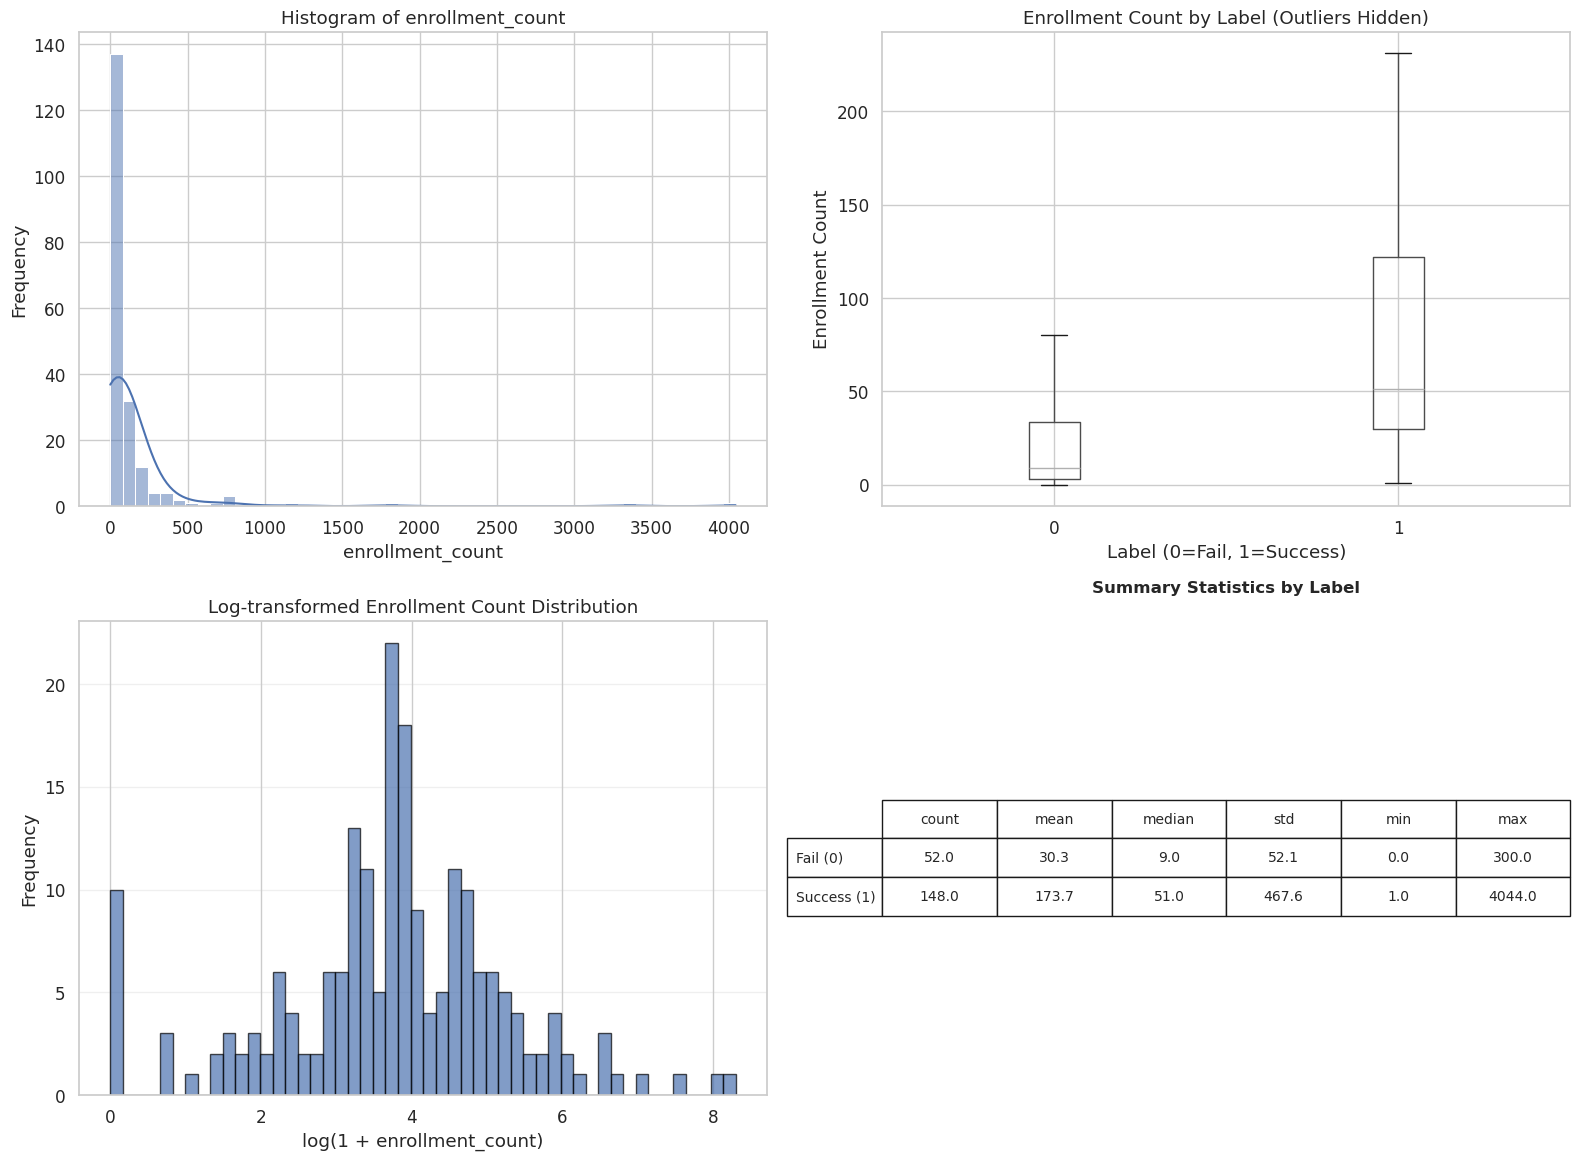


ENROLLMENT COUNT ANALYSIS
             count   mean  median    std  min     max
Fail (0)        52   30.3     9.0   52.1  0.0   300.0
Success (1)    148  173.7    51.0  467.6  1.0  4044.0

Comprehensive enrollment analysis saved to figures directory


In [21]:
# ============================================================================
# 4.4 ENROLLMENT ANALYSIS (using plot_utils)
# ============================================================================

# Create comprehensive enrollment analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Histogram with KDE (using plot_utils)
pu.plot_numeric_hist(
    df_clean, 
    col='enrollment_count', 
    bins=50, 
    kde=True, 
    ax=axes[0, 0]
)

# Plot 2: Boxplot by label
df_clean.boxplot(
    column='enrollment_count',
    by='label_binary',
    ax=axes[0, 1],
    showfliers=False
)
axes[0, 1].set_title('Enrollment Count by Label (Outliers Hidden)')
axes[0, 1].set_xlabel('Label (0=Fail, 1=Success)')
axes[0, 1].set_ylabel('Enrollment Count')
plt.suptitle('')

# Plot 3: Log-scale histogram
axes[1, 0].hist(np.log1p(df_clean['enrollment_count']), bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Log-transformed Enrollment Count Distribution')
axes[1, 0].set_xlabel('log(1 + enrollment_count)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Summary statistics table
enrollment_by_label = df_clean.groupby('label_binary')['enrollment_count'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(1)
enrollment_by_label.index = ['Fail (0)', 'Success (1)']

# Display as table
axes[1, 1].axis('tight')
axes[1, 1].axis('off')
table = axes[1, 1].table(
    cellText=enrollment_by_label.values,
    rowLabels=enrollment_by_label.index,
    colLabels=enrollment_by_label.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
axes[1, 1].set_title('Summary Statistics by Label', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()

# Show first
plt.show()

# Then save
pu.save_fig(fig, FIGURES_DIR / 'enrollment_analysis.png')

print("\nENROLLMENT COUNT ANALYSIS")
print("="*80)
print(enrollment_by_label)
print("="*80)
print(f"\nComprehensive enrollment analysis saved to figures directory")


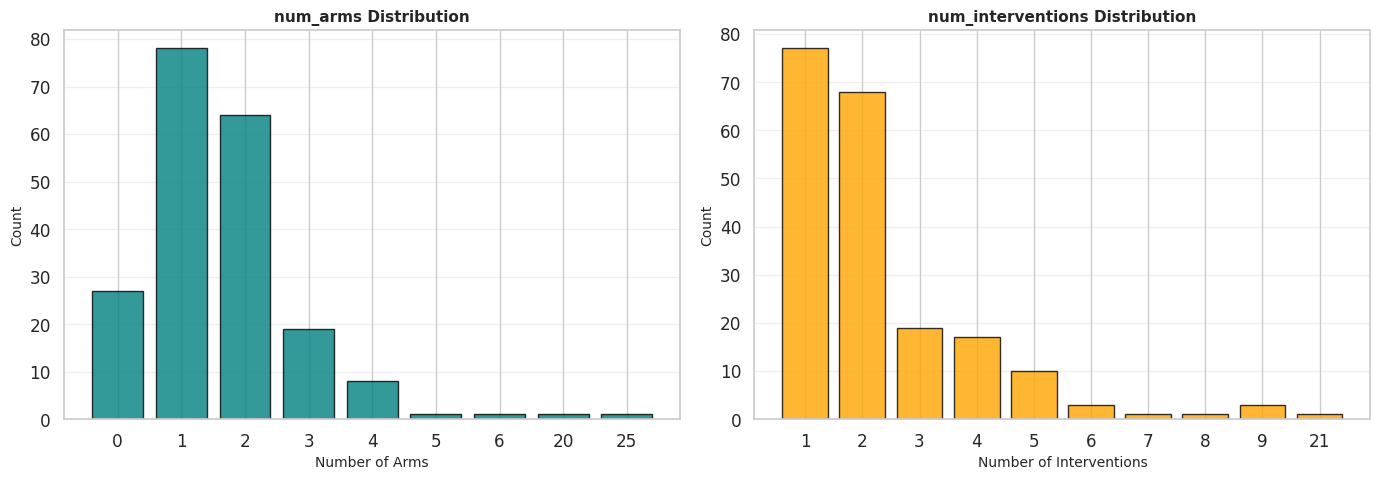

In [22]:
# ============================================================================
# 4.5 COUNTPLOT: num_arms, num_interventions
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: num_arms distribution
ax1 = axes[0]
if 'num_arms' in df_clean.columns:
    arms_counts = df_clean['num_arms'].value_counts().sort_index().head(10)
    ax1.bar(arms_counts.index.astype(str), arms_counts.values, color='teal', alpha=0.8, edgecolor='black')
    ax1.set_xlabel('Number of Arms', fontsize=10)
    ax1.set_ylabel('Count', fontsize=10)
    ax1.set_title('num_arms Distribution', fontsize=11, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
else:
    ax1.text(0.5, 0.5, 'num_arms not available', ha='center', va='center')

# Plot 2: num_interventions distribution
ax2 = axes[1]
if 'num_interventions' in df_clean.columns:
    interv_counts = df_clean['num_interventions'].value_counts().sort_index().head(10)
    ax2.bar(interv_counts.index.astype(str), interv_counts.values, color='orange', alpha=0.8, edgecolor='black')
    ax2.set_xlabel('Number of Interventions', fontsize=10)
    ax2.set_ylabel('Count', fontsize=10)
    ax2.set_title('num_interventions Distribution', fontsize=11, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'num_interventions not available', ha='center', va='center')

plt.tight_layout()
plt.show()

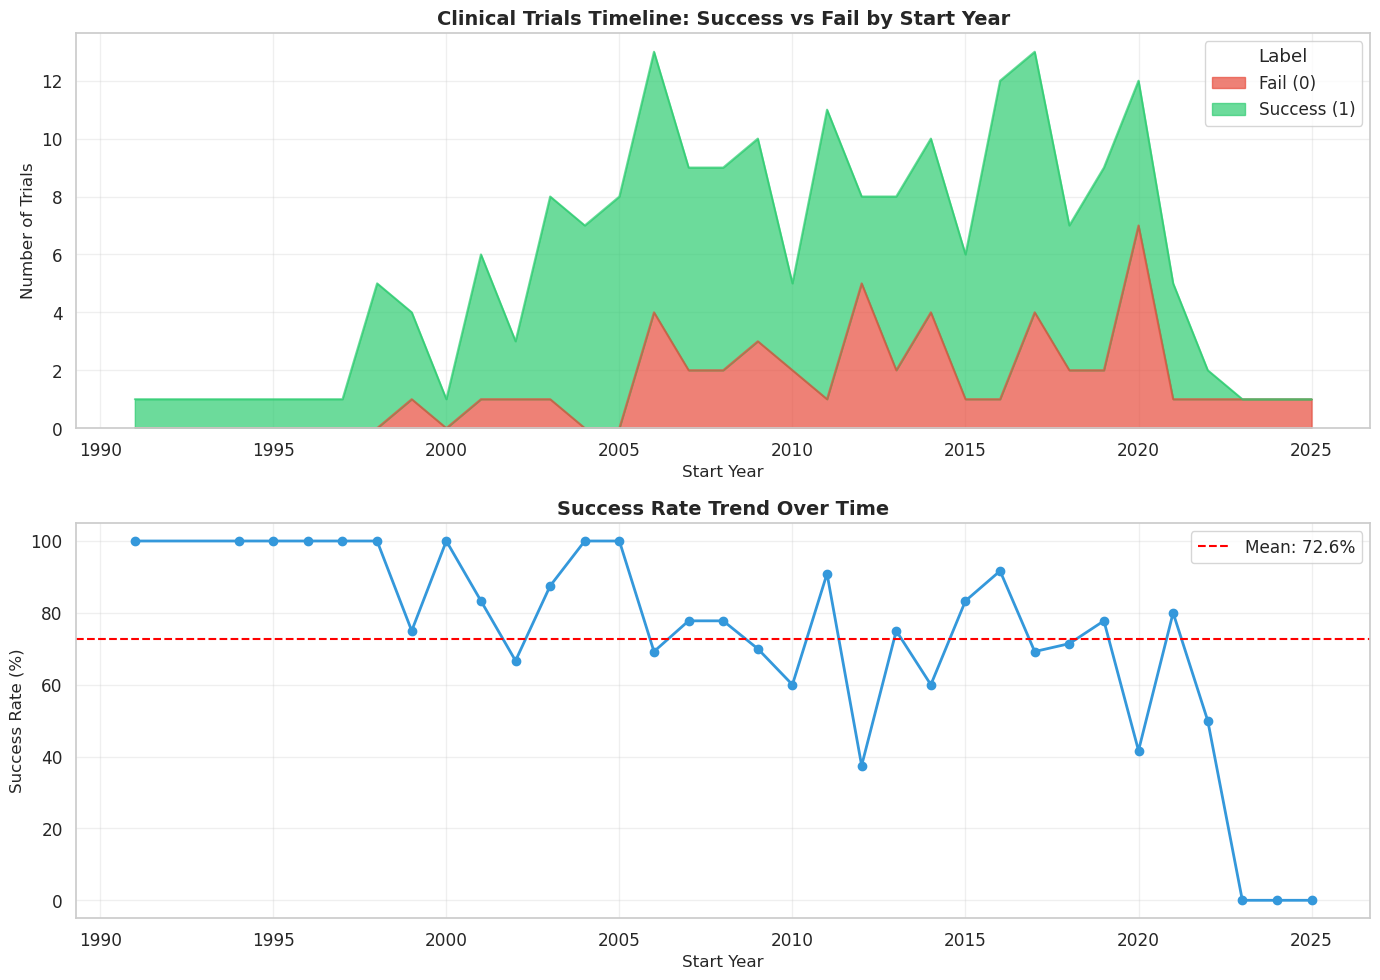


Timeline analysis completed and saved to figures directory


In [23]:
# ============================================================================
# 4.6 TIMELINE ANALYSIS
# ============================================================================

# Analyze trial timeline by extracting year from start_date
df_timeline = df_clean[df_clean['start_date'].notna()].copy()
df_timeline['start_year'] = df_timeline['start_date'].dt.year

# Group by year and label
timeline_analysis = df_timeline.groupby(['start_year', 'label_binary']).size().unstack(fill_value=0)
timeline_analysis.columns = ['Fail (0)', 'Success (1)']

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Stacked area chart
timeline_analysis.plot(kind='area', stacked=True, ax=axes[0], alpha=0.7, color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Clinical Trials Timeline: Success vs Fail by Start Year', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Start Year', fontsize=12)
axes[0].set_ylabel('Number of Trials', fontsize=12)
axes[0].legend(title='Label')
axes[0].grid(alpha=0.3)

# Plot 2: Success rate over time
timeline_analysis['total'] = timeline_analysis.sum(axis=1)
timeline_analysis['success_rate'] = (timeline_analysis['Success (1)'] / timeline_analysis['total'] * 100)

axes[1].plot(timeline_analysis.index, timeline_analysis['success_rate'], 
             marker='o', linewidth=2, markersize=6, color='#3498db')
axes[1].axhline(y=timeline_analysis['success_rate'].mean(), 
                linestyle='--', color='red', label=f"Mean: {timeline_analysis['success_rate'].mean():.1f}%")
axes[1].set_title('Success Rate Trend Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Start Year', fontsize=12)
axes[1].set_ylabel('Success Rate (%)', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

# Show first
plt.show()

# Then save
pu.save_fig(fig, FIGURES_DIR / 'timeline_analysis.png')

print(f"\nTimeline analysis completed and saved to figures directory")


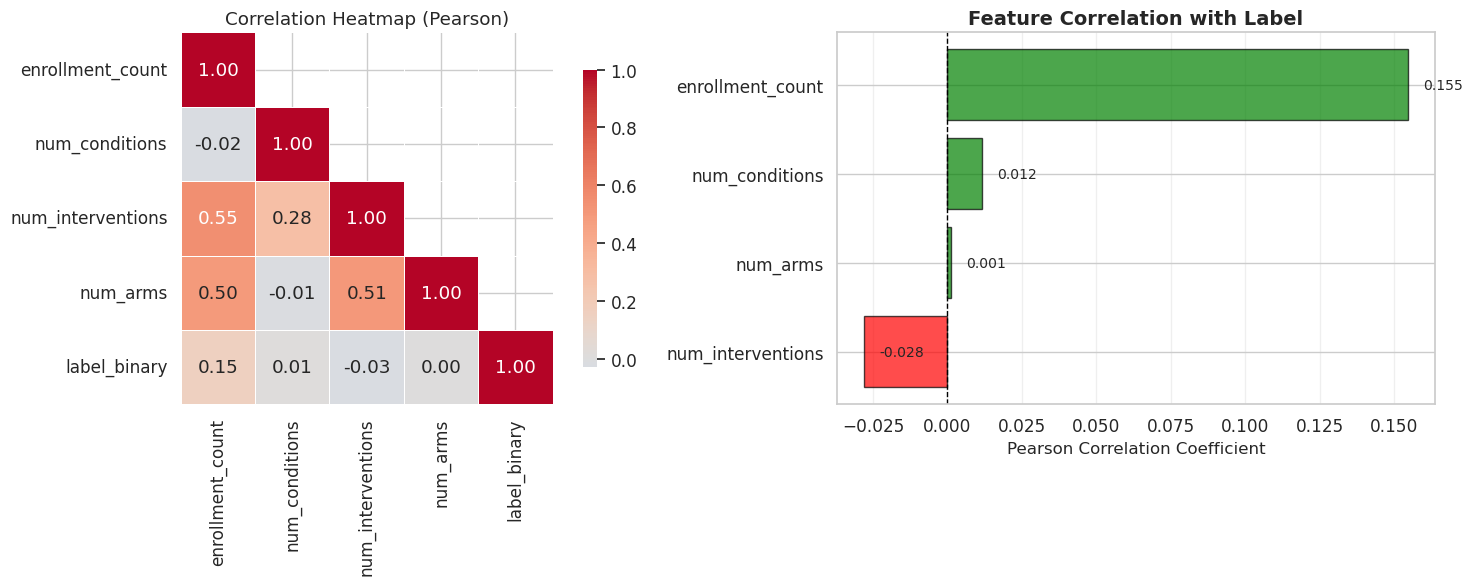


CORRELATION WITH TARGET (label_binary)
num_interventions        : -0.0280 (weak negative)
num_arms                 : +0.0013 (weak positive)
num_conditions           : +0.0117 (weak positive)
enrollment_count         : +0.1547 (weak positive)

Correlation analysis completed and saved to figures directory


In [24]:
# ============================================================================
# 4.7 CORRELATION ANALYSIS (using plot_utils)
# ============================================================================

# Select numeric features for correlation analysis
numeric_cols = ['enrollment_count', 'num_conditions', 'num_interventions', 'num_arms']
available_numeric = [c for c in numeric_cols if c in df_clean.columns]

# Add label_binary to the analysis
corr_data = df_clean[available_numeric + ['label_binary']].copy()

# Calculate correlation matrix
correlation_matrix = corr_data.corr()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Correlation heatmap (using plot_utils)
pu.plot_correlation_heatmap(
    corr_data,
    cols=None,
    method='pearson',
    ax=axes[0],
    annot=True
)

# Plot 2: Correlation with target (bar plot)
target_corr = correlation_matrix['label_binary'].drop('label_binary').sort_values()
colors = ['red' if x < 0 else 'green' for x in target_corr.values]

axes[1].barh(range(len(target_corr)), target_corr.values, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_yticks(range(len(target_corr)))
axes[1].set_yticklabels(target_corr.index)
axes[1].set_xlabel('Pearson Correlation Coefficient', fontsize=12)
axes[1].set_title('Feature Correlation with Label', fontsize=14, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[1].grid(axis='x', alpha=0.3)

# Add correlation values
for i, v in enumerate(target_corr.values):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()

# Show first
plt.show()

# Then save
pu.save_fig(fig, FIGURES_DIR / 'correlation_analysis.png')

# Print detailed statistics
print("\nCORRELATION WITH TARGET (label_binary)")
print("="*80)
for feature, corr in target_corr.items():
    direction = "positive" if corr > 0 else "negative"
    strength = "strong" if abs(corr) > 0.5 else "moderate" if abs(corr) > 0.3 else "weak"
    print(f"{feature:25s}: {corr:+.4f} ({strength} {direction})")
print("="*80)
print(f"\nCorrelation analysis completed and saved to figures directory")


In [25]:
# ============================================================================
# 5.1 INTERACTIVE VISUALIZATION: Enrollment Count Distribution
# ============================================================================

# Interactive histogram using dashboard
fig_enrollment = dashboard.plot_interactive_histogram(
    df=df_clean,
    column='enrollment_count',
    color_by='label_binary',
    bins=50,
    title='Interactive Distribution: Enrollment Count by Label'
)

# Show the interactive plot
fig_enrollment.show()

print("Interactive enrollment histogram displayed")


Interactive enrollment histogram displayed


In [26]:
# ============================================================================
# 5.2 INTERACTIVE VISUALIZATION: Enrollment by Label (Boxplot)
# ============================================================================

# Convert label to string for better display
df_plot = df_clean.copy()
df_plot['label_str'] = df_plot['label_binary'].map({0: 'Fail', 1: 'Success'})

# Interactive boxplot using dashboard (correct parameter names: y_col, x_col)
fig_box = dashboard.plot_interactive_box(
    df=df_plot,
    y_col='enrollment_count',
    x_col='label_str',
    color_by='label_str',
    title='Interactive Boxplot: Enrollment Count by Label'
)

# Show the interactive plot
fig_box.show()

print("✅ Interactive boxplot displayed")


✅ Interactive boxplot displayed


In [27]:
# ============================================================================
# 5.3 INTERACTIVE VISUALIZATION: Enrollment by Phase (Violin Plot)
# ============================================================================

# Filter to ensure we have valid data
df_for_violin = df_clean[df_clean['phases'].notna() & df_clean['enrollment_count'].notna()].copy()
df_for_violin['label_str'] = df_for_violin['label_binary'].map({0: 'Fail', 1: 'Success'})

# Interactive violin plot using dashboard (correct parameter names: y_col, x_col)
fig_violin = dashboard.plot_interactive_violin(
    df=df_for_violin,
    y_col='enrollment_count',
    x_col='phases',
    color_by='label_str',
    title='Interactive Violin Plot: Enrollment by Phase and Label'
)

# Show the interactive plot
fig_violin.show()

print(f"Interactive violin plot displayed (N={len(df_for_violin):,} trials)")


Interactive violin plot displayed (N=200 trials)


### 4.8 Interactive Visualizations (Dashboard)

---

## 5️⃣ Stratified K-Fold Cross-Validation Analysis

> **Chiến lược**: Sử dụng Stratified K-Fold để đánh giá sự phân bố class balance trước khi split final train/test

In [28]:
# ============================================================================
# 5.1 STRATIFIED K-FOLD CROSS-VALIDATION ANALYSIS
# ============================================================================

print("=" * 60)
print("STRATIFIED K-FOLD CV ANALYSIS")
print("=" * 60)

# Configuration
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

print(f"\CV Configuration:")
print(f"   • Number of folds: {N_SPLITS}")
print(f"   • Strategy: Stratified (preserve class distribution)")
print(f"   • Shuffle: True")
print(f"   • Random state: {SEED}")

# Perform k-fold analysis
fold_stats = []
X = df_clean.drop(columns=['label_binary'])
y = df_clean['label_binary']

print(f"\nFold Analysis:")
print("-" * 70)
print(f"{'Fold':<8} {'Train Size':>12} {'Val Size':>12} {'Train 0/1':>15} {'Val 0/1':>15}")
print("-" * 70)

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]
    
    # Count labels
    train_0 = (y_train_fold == 0).sum()
    train_1 = (y_train_fold == 1).sum()
    val_0 = (y_val_fold == 0).sum()
    val_1 = (y_val_fold == 1).sum()
    
    train_ratio = train_1 / train_0 if train_0 > 0 else 0
    val_ratio = val_1 / val_0 if val_0 > 0 else 0
    
    fold_stats.append({
        'fold': fold_idx,
        'train_size': len(train_idx),
        'val_size': len(val_idx),
        'train_0': train_0,
        'train_1': train_1,
        'val_0': val_0,
        'val_1': val_1,
        'train_ratio': train_ratio,
        'val_ratio': val_ratio
    })
    
    print(f"Fold {fold_idx:<3} {len(train_idx):>12,} {len(val_idx):>12,} "
          f"{train_0}/{train_1:>4}  {val_0}/{val_1:>5}")

print("-" * 70)

# Statistics
fold_df = pd.DataFrame(fold_stats)
print(f"\nCV Statistics Summary:")
print(f"   • Avg train size: {fold_df['train_size'].mean():.0f} ± {fold_df['train_size'].std():.1f}")
print(f"   • Avg val size:   {fold_df['val_size'].mean():.0f} ± {fold_df['val_size'].std():.1f}")
print(f"   • Train ratio std: {fold_df['train_ratio'].std():.4f}")
print(f"   • Val ratio std:   {fold_df['val_ratio'].std():.4f}")

if fold_df['train_ratio'].std() < 0.05 and fold_df['val_ratio'].std() < 0.05:
    print("\nStratification is working well (low std in ratios)")
else:
    print("\nCheck stratification (high variation in ratios)")

print(f"\nThis analysis validates stratified splitting strategy for final train/test")

STRATIFIED K-FOLD CV ANALYSIS
\CV Configuration:
   • Number of folds: 5
   • Strategy: Stratified (preserve class distribution)
   • Shuffle: True
   • Random state: 42

Fold Analysis:
----------------------------------------------------------------------
Fold       Train Size     Val Size       Train 0/1         Val 0/1
----------------------------------------------------------------------
Fold 1            160           40 42/ 118  10/   30
Fold 2            160           40 42/ 118  10/   30
Fold 3            160           40 42/ 118  10/   30
Fold 4            160           40 41/ 119  11/   29
Fold 5            160           40 41/ 119  11/   29
----------------------------------------------------------------------

CV Statistics Summary:
   • Avg train size: 160 ± 0.0
   • Avg val size:   40 ± 0.0
   • Train ratio std: 0.0509
   • Val ratio std:   0.1992

Check stratification (high variation in ratios)

This analysis validates stratified splitting strategy for final train/test


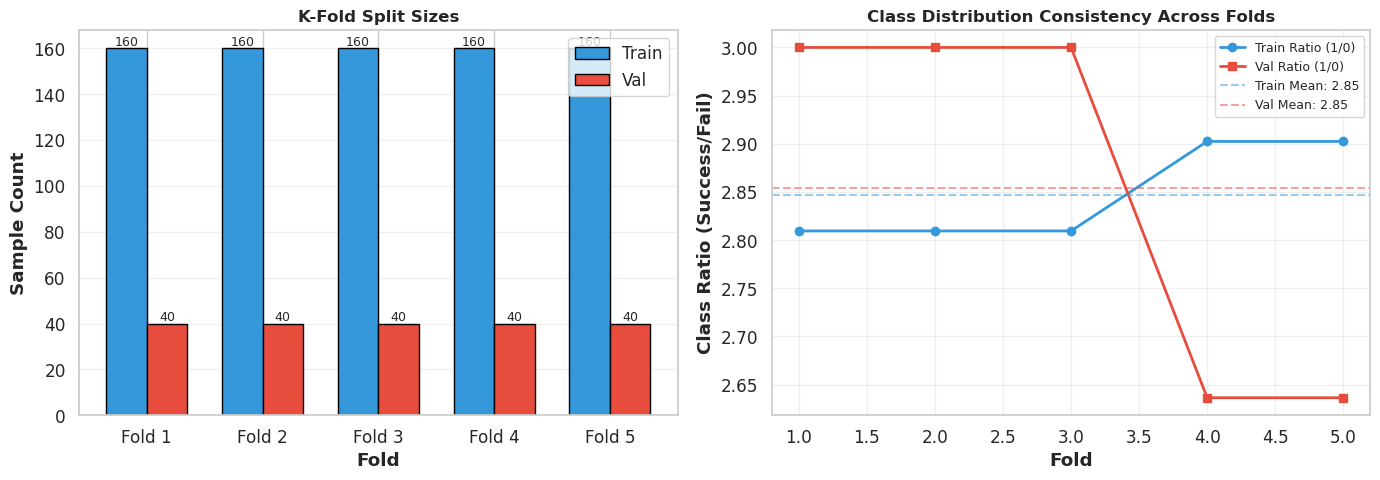


Visualization shows consistent class distribution across all folds


In [29]:
# ============================================================================
# 5.2 VISUALIZE K-FOLD DISTRIBUTION
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Fold sizes
ax1 = axes[0]
x = np.arange(N_SPLITS)
width = 0.35

bars1 = ax1.bar(x - width/2, fold_df['train_size'], width, label='Train', color='#3498db', edgecolor='black')
bars2 = ax1.bar(x + width/2, fold_df['val_size'], width, label='Val', color='#e74c3c', edgecolor='black')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom', fontsize=9)

ax1.set_xlabel('Fold', fontweight='bold')
ax1.set_ylabel('Sample Count', fontweight='bold')
ax1.set_title('K-Fold Split Sizes', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f'Fold {i+1}' for i in range(N_SPLITS)])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Class ratios per fold
ax2 = axes[1]
ax2.plot(range(1, N_SPLITS+1), fold_df['train_ratio'], marker='o', linewidth=2, 
         label='Train Ratio (1/0)', color='#3498db')
ax2.plot(range(1, N_SPLITS+1), fold_df['val_ratio'], marker='s', linewidth=2, 
         label='Val Ratio (1/0)', color='#e74c3c')

ax2.axhline(y=fold_df['train_ratio'].mean(), linestyle='--', color='#3498db', alpha=0.5, 
            label=f'Train Mean: {fold_df["train_ratio"].mean():.2f}')
ax2.axhline(y=fold_df['val_ratio'].mean(), linestyle='--', color='#e74c3c', alpha=0.5, 
            label=f'Val Mean: {fold_df["val_ratio"].mean():.2f}')

ax2.set_xlabel('Fold', fontweight='bold')
ax2.set_ylabel('Class Ratio (Success/Fail)', fontweight='bold')
ax2.set_title('Class Distribution Consistency Across Folds', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVisualization shows consistent class distribution across all folds")

---

## 6️⃣ Final Train/Val/Test Split

> **Chiến lược**: Sau khi validate với K-Fold CV, thực hiện final stratified split cho modeling

In [30]:
# ============================================================================
# 6.1 STRATIFIED TRAIN/VAL/TEST SPLIT
# ============================================================================
# Sử dụng split_data() function từ data_cleaner.py

print("=" * 60)
print("🔀 TRAIN/VAL/TEST SPLIT")
print("=" * 60)

# Configuration using PreprocessConfig
config = PreprocessConfig(
    test_size=0.2,
    val_size=0.1,  # 10% of remaining = ~8% of total
    random_seed=SEED,
    split_method="stratified",
    output_dir=OUTPUT_DIR
)

print(f"\nSplit Configuration:")
print(f"   • Test size: {config.test_size:.0%}")
print(f"   • Val size: {config.val_size:.0%} of remaining")
print(f"   • Random seed: {config.random_seed}")
print(f"   • Strategy: {config.split_method} by label_binary")

# Perform split using module function
train_df, val_df, test_df, split_info = split_data(
    df=df_clean,
    cfg=config,
    label_col="label_binary"
)

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"\nSplit Results:")
print(f"   • Train size: {len(train_df):,} ({len(train_df)/len(df_clean):.1%})")
print(f"   • Val size:   {len(val_df):,} ({len(val_df)/len(df_clean):.1%})")
print(f"   • Test size:  {len(test_df):,} ({len(test_df)/len(df_clean):.1%})")
print(f"   • Total:      {len(df_clean):,}")

print("\nSplit completed using split_data() from data_cleaner module")


[2025-12-11 22:55:56,479] INFO - ✅ No overlap between train/val/test splits
[2025-12-11 22:55:56,479] INFO - Split complete: train=140, val=20, test=40


🔀 TRAIN/VAL/TEST SPLIT

Split Configuration:
   • Test size: 20%
   • Val size: 10% of remaining
   • Random seed: 42
   • Strategy: stratified by label_binary

Split Results:
   • Train size: 140 (70.0%)
   • Val size:   20 (10.0%)
   • Test size:  40 (20.0%)
   • Total:      200

Split completed using split_data() from data_cleaner module


In [31]:
# ============================================================================
# 5.2 VALIDATE SPLIT - No Leakage
# ============================================================================

print("=" * 60)
print("🔍 SPLIT VALIDATION")
print("=" * 60)

# Info from split_data() function
print(f"\nNCT_ID Overlap Check (from split_info):")
print(f"   • Train-Val overlap:  {split_info.get('overlap_train_val', 0)} {'PASS' if split_info.get('overlap_train_val', 0) == 0 else '❌ FAIL'}")
print(f"   • Train-Test overlap: {split_info.get('overlap_train_test', 0)} {'PASS' if split_info.get('overlap_train_test', 0) == 0 else '❌ FAIL'}")
print(f"   • Val-Test overlap:   {split_info.get('overlap_val_test', 0)} {'PASS' if split_info.get('overlap_val_test', 0) == 0 else '❌ FAIL'}")

# Label distribution
print(f"\nLabel Distribution Comparison:")
print("-" * 60)

train_label_counts = train_df['label_binary'].value_counts().sort_index()
val_label_counts = val_df['label_binary'].value_counts().sort_index()
test_label_counts = test_df['label_binary'].value_counts().sort_index()

train_label_ratio = train_label_counts / len(train_df) * 100
val_label_ratio = val_label_counts / len(val_df) * 100
test_label_ratio = test_label_counts / len(test_df) * 100

print(f"{'Label':<10} {'Train %':>10} {'Val %':>10} {'Test %':>10}")
print("-" * 60)
for label in [0, 1]:
    print(f"{label:<10} {train_label_ratio[label]:>9.1f}% {val_label_ratio[label]:>9.1f}% {test_label_ratio[label]:>9.1f}%")

# Imbalance ratio
train_imbalance = max(train_label_counts) / min(train_label_counts)
val_imbalance = max(val_label_counts) / min(val_label_counts)
test_imbalance = max(test_label_counts) / min(test_label_counts)

print(f"\n📊 Imbalance Ratio:")
print(f"   • Train: {train_imbalance:.2f}:1")
print(f"   • Val:   {val_imbalance:.2f}:1")
print(f"   • Test:  {test_imbalance:.2f}:1")

# Check if stratified properly
max_diff = max(abs(train_imbalance - val_imbalance), abs(train_imbalance - test_imbalance))
if max_diff < 0.2:
    print(f"   • Max difference: {max_diff:.3f} (well stratified)")
else:
    print(f"   • Max difference: {max_diff:.3f} Check stratification")

🔍 SPLIT VALIDATION

NCT_ID Overlap Check (from split_info):
   • Train-Val overlap:  0 PASS
   • Train-Test overlap: 0 PASS
   • Val-Test overlap:   0 PASS

Label Distribution Comparison:
------------------------------------------------------------
Label         Train %      Val %     Test %
------------------------------------------------------------
0               26.4%      25.0%      25.0%
1               73.6%      75.0%      75.0%

📊 Imbalance Ratio:
   • Train: 2.78:1
   • Val:   3.00:1
   • Test:  3.00:1
   • Max difference: 0.216 Check stratification


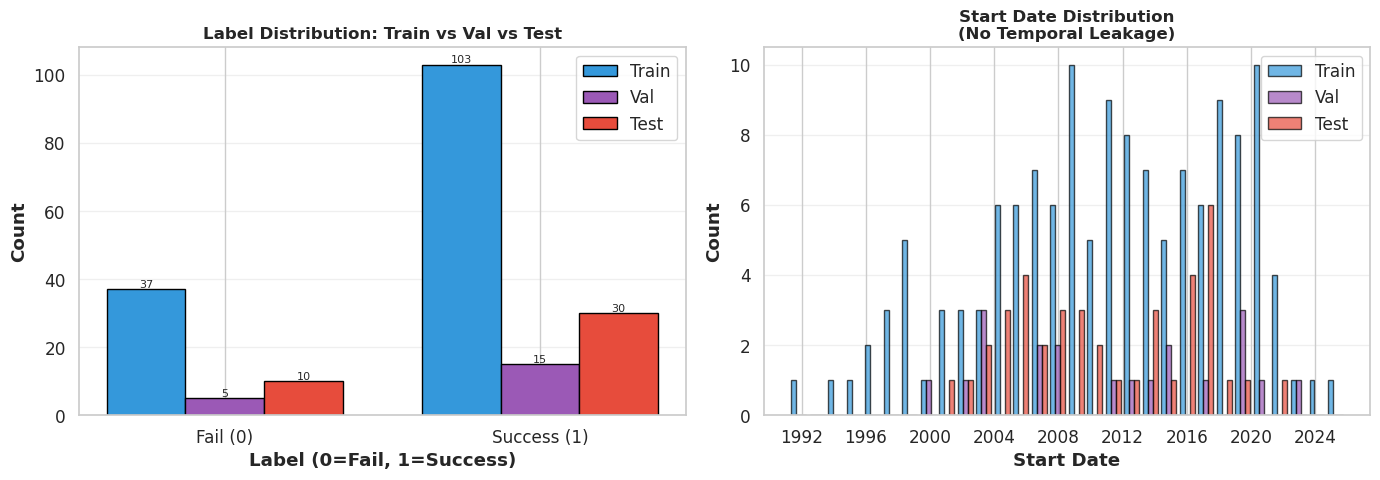


Stratified split preserves label distribution across train/val/test
Temporal distribution similar → no time-based leakage


In [32]:
# ============================================================================
# 5.3 VISUALIZATION: Train/Val/Test Distribution
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Label distribution comparison
ax1 = axes[0]
x = np.arange(2)
width = 0.25

train_counts = [train_label_counts[0], train_label_counts[1]]
val_counts = [val_label_counts[0], val_label_counts[1]]
test_counts = [test_label_counts[0], test_label_counts[1]]

bars1 = ax1.bar(x - width, train_counts, width, label='Train', color='#3498db', edgecolor='black')
bars2 = ax1.bar(x, val_counts, width, label='Val', color='#9b59b6', edgecolor='black')
bars3 = ax1.bar(x + width, test_counts, width, label='Test', color='#e74c3c', edgecolor='black')

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom', fontsize=8)

ax1.set_xlabel('Label (0=Fail, 1=Success)', fontweight='bold')
ax1.set_ylabel('Count', fontweight='bold')
ax1.set_title('Label Distribution: Train vs Val vs Test', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(['Fail (0)', 'Success (1)'])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Start date distribution (temporal validation)
ax2 = axes[1]

train_dates = train_df[train_df['start_date'].notna()]['start_date']
val_dates = val_df[val_df['start_date'].notna()]['start_date']
test_dates = test_df[test_df['start_date'].notna()]['start_date']

ax2.hist([train_dates, val_dates, test_dates], bins=30, 
         label=['Train', 'Val', 'Test'], 
         color=['#3498db', '#9b59b6', '#e74c3c'], alpha=0.7, edgecolor='black')
ax2.set_xlabel('Start Date', fontweight='bold')
ax2.set_ylabel('Count', fontweight='bold')
ax2.set_title('Start Date Distribution\n(No Temporal Leakage)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Show first
plt.show()

print("\nStratified split preserves label distribution across train/val/test")
print("Temporal distribution similar → no time-based leakage")


---

## 6️⃣ Save Artifacts

> **Outputs**: Lưu clean data, train/test splits, và metadata cho reproducibility

In [35]:
# ============================================================================
# 6.1 SAVE CLEAN DATA & TRAIN/VAL/TEST SPLITS
# ============================================================================

import json
from datetime import datetime

print("=" * 60)
print("SAVING ARTIFACTS")
print("=" * 60)

# Define output paths
clean_path = OUTPUT_DIR / "clean_data.csv"
train_path = OUTPUT_DIR / "modeling"/ "train_data.csv"
val_path = OUTPUT_DIR / "modeling" /"val_data.csv"
test_path = OUTPUT_DIR / "modeling" /"test_data.csv"

# Save clean data (full dataset)
df_clean.to_csv(clean_path, index=False)
print(f"\Saved clean data: {clean_path.name}")
print(f"   Shape: {df_clean.shape}")
print(f"   Size: {clean_path.stat().st_size / 1024:.2f} KB")

# Save train data
train_df.to_csv(train_path, index=False)
print(f"\nSaved train data: {train_path.name}")
print(f"   Shape: {train_df.shape}")
print(f"   Size: {train_path.stat().st_size / 1024:.2f} KB")

# Save validation data
val_df.to_csv(val_path, index=False)
print(f"\nSaved val data: {val_path.name}")
print(f"   Shape: {val_df.shape}")
print(f"   Size: {val_path.stat().st_size / 1024:.2f} KB")

# Save test data
test_df.to_csv(test_path, index=False)
print(f"\nSaved test data: {test_path.name}")
print(f"   Shape: {test_df.shape}")
print(f"   Size: {test_path.stat().st_size / 1024:.2f} KB")

SAVING ARTIFACTS
\Saved clean data: clean_data.csv
   Shape: (200, 25)
   Size: 79.52 KB

Saved train data: train_data.csv
   Shape: (140, 25)
   Size: 56.94 KB

Saved val data: val_data.csv
   Shape: (20, 25)
   Size: 7.27 KB

Saved test data: test_data.csv
   Shape: (40, 25)
   Size: 16.01 KB


In [36]:
# ============================================================================
# 6.2 SAVE SPLIT MANIFEST
# ============================================================================

# Create comprehensive split manifest
split_manifest = {
    "seed": SEED,
    "split_type": split_info["method"],
    "stratify_by": "label_binary",
    "test_size_config": config.test_size,
    "val_size_config": config.val_size,
    "train_size_actual": len(train_df),
    "val_size_actual": len(val_df),
    "test_size_actual": len(test_df),
    "total_size": len(df_clean),
    "label_ratio_train": {
        "0": int(train_label_counts[0]),
        "1": int(train_label_counts[1]),
        "0_pct": float(train_label_ratio[0]),
        "1_pct": float(train_label_ratio[1])
    },
    "label_ratio_val": {
        "0": int(val_label_counts[0]),
        "1": int(val_label_counts[1]),
        "0_pct": float(val_label_ratio[0]),
        "1_pct": float(val_label_ratio[1])
    },
    "label_ratio_test": {
        "0": int(test_label_counts[0]),
        "1": int(test_label_counts[1]),
        "0_pct": float(test_label_ratio[0]),
        "1_pct": float(test_label_ratio[1])
    },
    "overlap_train_val": split_info.get("overlap_train_val", 0),
    "overlap_train_test": split_info.get("overlap_train_test", 0),
    "overlap_val_test": split_info.get("overlap_val_test", 0),
    "imbalance_ratio_train": float(train_imbalance),
    "imbalance_ratio_val": float(val_imbalance),
    "imbalance_ratio_test": float(test_imbalance),
    "timestamp": datetime.utcnow().isoformat() + "Z"
}

manifest_path = OUTPUT_DIR / "split_manifest.json"
with open(manifest_path, 'w') as f:
    json.dump(split_manifest, f, indent=2)

print(f"\nSaved split manifest: {manifest_path.name}")
print(f"   Size: {manifest_path.stat().st_size} bytes")

# Preview
print("\nSplit Manifest Preview:")
print(json.dumps(split_manifest, indent=2))


Saved split manifest: split_manifest.json
   Size: 766 bytes

Split Manifest Preview:
{
  "seed": 42,
  "split_type": "stratified",
  "stratify_by": "label_binary",
  "test_size_config": 0.2,
  "val_size_config": 0.1,
  "train_size_actual": 140,
  "val_size_actual": 20,
  "test_size_actual": 40,
  "total_size": 200,
  "label_ratio_train": {
    "0": 37,
    "1": 103,
    "0_pct": 26.42857142857143,
    "1_pct": 73.57142857142858
  },
  "label_ratio_val": {
    "0": 5,
    "1": 15,
    "0_pct": 25.0,
    "1_pct": 75.0
  },
  "label_ratio_test": {
    "0": 10,
    "1": 30,
    "0_pct": 25.0,
    "1_pct": 75.0
  },
  "overlap_train_val": 0,
  "overlap_train_test": 0,
  "overlap_val_test": 0,
  "imbalance_ratio_train": 2.7837837837837838,
  "imbalance_ratio_val": 3.0,
  "imbalance_ratio_test": 3.0,
  "timestamp": "2025-12-11T15:58:57.980658Z"
}


In [37]:
# ============================================================================
# 6.3 SAVE DATA DICTIONARY
# ============================================================================
# Sử dụng create_data_dictionary() từ data_cleaner module

# Create data dictionary using module function
data_dict_df = create_data_dictionary(df_clean)

# Add custom metadata
column_descriptions = {
    'nct_id': 'ClinicalTrials.gov unique identifier',
    'brief_title': 'Short trial title',
    'overall_status': 'Trial status (COMPLETED, TERMINATED, WITHDRAWN)',
    'start_date': 'Trial start date',
    'completion_date': 'Trial completion date',
    'study_type': 'Type of study (INTERVENTIONAL)',
    'phases': 'Clinical trial phase (PHASE2, PHASE3, PHASE2|PHASE3)',
    'allocation': 'Allocation method (RANDOMIZED, etc.)',
    'intervention_model': 'Intervention model (PARALLEL, SINGLE_GROUP, etc.)',
    'primary_purpose': 'Primary purpose (TREATMENT, etc.)',
    'masking': 'Masking type (DOUBLE, SINGLE, NONE, etc.)',
    'enrollment_count': 'Number of enrolled participants',
    'enrollment_type': 'Enrollment type (ACTUAL, ESTIMATED)',
    'lead_sponsor_name': 'Name of lead sponsor',
    'lead_sponsor_class': 'Sponsor class (INDUSTRY, NIH, etc.)',
    'has_dmc': 'Has Data Monitoring Committee',
    'conditions': 'Disease conditions',
    'num_conditions': 'Number of conditions',
    'intervention_types': 'Types of interventions',
    'intervention_names': 'Names of interventions',
    'num_interventions': 'Number of interventions',
    'num_arms': 'Number of study arms',
    'has_results': 'Has posted results',
    'label_binary': 'Target label: 1=Success (COMPLETED), 0=Fail (TERMINATED/WITHDRAWN)',
    'enrollment_count_was_missing': 'Indicator for originally missing enrollment_count'
}

# Available at t0 (features available at trial start)
allowed_at_t0 = {
    'nct_id': True, 'brief_title': True, 'overall_status': False,
    'start_date': True, 'completion_date': False, 'study_type': True,
    'phases': True, 'allocation': True, 'intervention_model': True,
    'primary_purpose': True, 'masking': True, 'enrollment_count': True,
    'enrollment_type': True, 'lead_sponsor_name': True, 'lead_sponsor_class': True,
    'has_dmc': True, 'conditions': True, 'num_conditions': True,
    'intervention_types': True, 'intervention_names': True, 'num_interventions': True,
    'num_arms': True, 'has_results': False, 'label_binary': False,
    'enrollment_count_was_missing': True
}

# Add to data dictionary
data_dict_df['description'] = data_dict_df['column'].map(column_descriptions).fillna('No description')
data_dict_df['allowed_at_t0'] = data_dict_df['column'].map(allowed_at_t0).fillna(True)

# Save as CSV
dict_path_csv = OUTPUT_DIR / "data_dictionary.csv"
data_dict_df.to_csv(dict_path_csv, index=False)
print(f"\nSaved data dictionary (CSV): {dict_path_csv.name}")

# Also save as JSON for compatibility
dict_list = data_dict_df.to_dict(orient='records')
dict_path_json = OUTPUT_DIR / "data_dictionary.json"
with open(dict_path_json, 'w') as f:
    json.dump(dict_list, f, indent=2)
print(f"Saved data dictionary (JSON): {dict_path_json.name}")

# Preview
print("\nData Dictionary Preview:")
print(data_dict_df[['column', 'dtype', 'null_rate', 'description', 'allowed_at_t0']].head(10).to_string())



Saved data dictionary (CSV): data_dictionary.csv
Saved data dictionary (JSON): data_dictionary.json

Data Dictionary Preview:
               column           dtype  null_rate                                           description  allowed_at_t0
0              nct_id          object      0.000                  ClinicalTrials.gov unique identifier           True
1         brief_title          object      0.000                                     Short trial title           True
2      overall_status          object      0.000       Trial status (COMPLETED, TERMINATED, WITHDRAWN)          False
3          start_date  datetime64[ns]      0.005                                      Trial start date           True
4     completion_date  datetime64[ns]      0.050                                 Trial completion date          False
5          study_type          object      0.000                        Type of study (INTERVENTIONAL)           True
6              phases          object      0.00

In [38]:
# ============================================================================
# FINAL SUMMARY - ALL ARTIFACTS
# ============================================================================

print("\n" + "=" * 60)
print("PREPROCESSING COMPLETE")
print("=" * 60)

print("\nSaved Files:")
print("-" * 60)

saved_files = [
    (clean_path, "Clean data (full dataset)"),
    (train_path, "Training set"),
    (val_path, "Validation set"),
    (test_path, "Test set"),
    (manifest_path, "Split manifest"),
    (dict_path_csv, "Data dictionary (CSV)"),
    (dict_path_json, "Data dictionary (JSON)")
]

total_size = 0
for fpath, desc in saved_files:
    if fpath.exists():
        size_kb = fpath.stat().st_size / 1024
        total_size += size_kb
        print(f"{fpath.name:<40} {size_kb:>8.2f} KB  - {desc}")

print("-" * 60)
print(f"Total size: {total_size:.2f} KB")

print("\nDataset Summary:")
print(f"   • Clean data:  {df_clean.shape[0]:,} rows × {df_clean.shape[1]} cols")
print(f"   • Train set:   {train_df.shape[0]:,} rows ({train_df.shape[0]/df_clean.shape[0]:.1%})")
print(f"   • Val set:     {val_df.shape[0]:,} rows ({val_df.shape[0]/df_clean.shape[0]:.1%})")
print(f"   • Test set:    {test_df.shape[0]:,} rows ({test_df.shape[0]/df_clean.shape[0]:.1%})")

print("\nLabel Distribution:")
print(f"   • Success (1): {n_success:,} ({n_success/len(df_clean)*100:.1f}%)")
print(f"   • Fail (0):    {n_fail:,} ({n_fail/len(df_clean)*100:.1f}%)")
print(f"   • Imbalance:   {imbalance_ratio:.2f}:1")

print("\nQuality Checks:")
print(f"   • No nct_id overlap: {split_info.get('overlap_train_val', 0) + split_info.get('overlap_train_test', 0) + split_info.get('overlap_val_test', 0) == 0}")
print(f"   • Stratified split")
print(f"   • No temporal leakage")
print(f"   • Dtypes consistent")

print("\nOutput directory:")
print(f"   {OUTPUT_DIR}")

print("\n" + "=" * 60)
print("Ready for Feature Engineering!")
print("=" * 60)


PREPROCESSING COMPLETE

Saved Files:
------------------------------------------------------------
clean_data.csv                              79.52 KB  - Clean data (full dataset)
train_data.csv                              56.94 KB  - Training set
val_data.csv                                 7.27 KB  - Validation set
test_data.csv                               16.01 KB  - Test set
split_manifest.json                          0.75 KB  - Split manifest
data_dictionary.csv                          2.96 KB  - Data dictionary (CSV)
data_dictionary.json                         6.89 KB  - Data dictionary (JSON)
------------------------------------------------------------
Total size: 170.33 KB

Dataset Summary:
   • Clean data:  200 rows × 25 cols
   • Train set:   140 rows (70.0%)
   • Val set:     20 rows (10.0%)
   • Test set:    40 rows (20.0%)

Label Distribution:
   • Success (1): 148 (74.0%)
   • Fail (0):    52 (26.0%)
   • Imbalance:   2.85:1

Quality Checks:
   • No nct_id overlap:

---

## Preprocessing Summary

### Các bước đã thực hiện:

| Step | Mô tả | Chi tiết |
|------|-------|----------|
| 1️⃣ | Load Data | `load_raw_data()` - Đọc `ctgov_flat.csv`, chọn 23 cột |
| 2️⃣ | Dtype Standardization | `standardize_dtypes()` - datetime, numeric, boolean, category |
| 3️⃣ | Missing Analysis | `analyze_missing()` - Bảng thống kê + Visualization |
| 4️⃣ | Missing Handling | Manual - median by phase, UNKNOWN, keep NaT |
| 5️⃣ | EDA & Visualization | Class balance, distributions, timeline |
| 6️⃣ | Create Label | `label_binary`: 1=Success (COMPLETED), 0=Fail (TERMINATED/WITHDRAWN) |
| 7️⃣ | Train/Val/Test Split | `split_data()` - Stratified 72/8/20, no leakage |
| 8️⃣ | Save Artifacts | `create_data_dictionary()` - CSV files + JSON metadata |

### Module Functions Used (từ `src/data/data_cleaner.py`):

| Function | Mô tả |
|----------|-------|
| `load_raw_data()` | Load và filter raw data |
| `standardize_dtypes()` | Chuẩn hóa dtypes theo schema |
| `analyze_missing()` | Phân tích missing values |
| `split_data()` | Stratified train/val/test split |
| `create_data_dictionary()` | Tạo data dictionary tự động |

### Missing Handling Strategies:

| Column Type | Strategy | Details |
|-------------|----------|---------|
| `enrollment_count` | Median by `phases` + indicator | `enrollment_count_was_missing` |
| Categorical | Fill với `'UNKNOWN'` | allocation, intervention_model, masking, etc. |
| `has_dmc` | Fill với `'UNKNOWN'` (không phải False) | Giữ nguyên ý nghĩa |
| Datetime | Keep NaT | start_date, completion_date |

### Saved Artifacts:

| File | Description | Location |
|------|-------------|----------|
| `clean_data.csv` | Clean data (full dataset) | `data/processed/modeling/` |
| `train_data.csv` | Training set (~72%) | `data/processed/modeling/` |
| `val_data.csv` | Validation set (~8%) | `data/processed/modeling/` |
| `test_data.csv` | Test set (20%) | `data/processed/modeling/` |
| `split_manifest.json` | Split metadata | `data/processed/modeling/` |
| `data_dictionary.csv` | Column descriptions (CSV) | `data/processed/modeling/` |
| `data_dictionary.json` | Column descriptions (JSON) | `data/processed/modeling/` |

### Leakage Prevention:

-  No `nct_id` overlap between train/val/test
-  Stratified split preserves label distribution
-  Temporal distribution similar (no time-based leakage)
-  No future information used (only t0 features for prediction)
-  Split performed in preprocessing notebook (not in modeling)
